# When dots overlap: dense scatterplots and trend lines

**A practical, reproducible guide in Python** · 80,000 example observations · OLS and robust regression

Start with **hexbin counts on a logarithmic colour scale** when overlap hides where
observations concentrate. Pair this with a full-range view so sparse observations remain
visible. Fit trend lines to the original observations, including repeated coordinates.

This notebook compares six displays of the same data, then adds **ordinary least squares
(OLS)** and **Huber robust regression**. A separate curved example compares LOWESS with
and without robust residual reweighting. The recommendation is a starting point: the best
display depends on whether you need individual points, counts, or the overall distribution.

**Expanded gallery:** section 8 adds ten more options, from density contours and marginal
histograms to conditional heatmaps, violins, ridgelines, and subgroup facets.

| What you need to see | Start with | Main trade-off |
|:--|:--|:--|
| Individual points with moderate overlap | Small markers and transparency | Dense regions still saturate |
| Concentration under heavy overlap | Hexbin or a 2D histogram | Bin size controls visible detail |
| Repeated, rounded coordinates | Small, disclosed jitter or counts | Jitter moves points for display |
| A quick view of a huge dataset | A reproducible random sample | Rare groups can disappear |
| A central trend despite unusual y values | Huber regression alongside OLS | The fits answer different questions |

**Run:** use a Python 3 kernel and run all cells in order. Dependencies are in
`requirements.txt`; outputs are also embedded in this notebook. Set `CSV_PATH` in
section 1 to use your own CSV. No download is needed for the examples.

In [1]:
from pathlib import Path
from importlib.metadata import version
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from IPython.display import display, Markdown

SEED = 20260922
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

INK, BLUE, ORANGE, MAGENTA = "#172b3a", "#306d9b", "#d15a18", "#9b3375"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160,
    "figure.facecolor": "white", "axes.facecolor": "#f8fafc",
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.labelcolor": INK, "text.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#b6c3ce", "axes.grid": False,
    "legend.framealpha": 0.96, "legend.facecolor": "white",
    "xtick.color": "#476070", "ytick.color": "#476070",
})

def show_and_save(fig, name):
    fig.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Python {sys.version.split()[0]}")
print(" | ".join(f"{p} {version(p)}" for p in
                 ["numpy", "pandas", "matplotlib", "scipy", "statsmodels"]))

Python 3.13.1
numpy 2.2.4 | pandas 2.2.3 | matplotlib 3.10.1 | scipy 1.17.1 | statsmodels 0.14.6


## 1. Data with crowding, exact overlaps, and outliers

The default example has two densely populated x regions. Its main population follows
$y = 2 + 1.7x + \epsilon$, with a wider spread at larger $|x|$.
Four percent of the observations receive a large upward shift at positive x. Both
coordinates are rounded to 0.1, so many distinct observations occupy exactly the same spot.

The shifted points are deliberately constructed to illustrate the difference between the
regression methods. In real data, an unusual point might be an error, a valid rare event,
or a separate population. A robust fit does not decide which explanation is correct.

**Your data:** set `CSV_PATH = "your_data.csv"` and choose the two column names below.
Missing, nonnumeric, and infinite coordinate pairs are excluded and counted; duplicates
are retained. That assumes repeated rows represent repeated observations. Investigate
accidental duplicate records separately. The final LOWESS example remains synthetic.

In [2]:
CSV_PATH = None                 # e.g. "measurements.csv"
X_COLUMN, Y_COLUMN = "x", "y"
N = 80_000
OUTLIER_FRACTION = 0.04         # try 0.00 or 0.08, then rerun all cells
ROUNDING_STEP = 0.1             # known measurement resolution in the example
IS_SYNTHETIC = CSV_PATH is None

def make_demo(n=N, outlier_fraction=OUTLIER_FRACTION, seed=SEED):
    rng = np.random.default_rng(seed)
    n_shifted = int(n * outlier_fraction)
    n_main = n - n_shifted
    left = rng.random(n_main) < 0.62
    x_main = np.where(left, rng.normal(-1.2, 0.52, n_main),
                    rng.normal(1.3, 0.78, n_main))
    y_main = 2 + 1.7 * x_main + rng.normal(0, 0.50 + 0.18 * np.abs(x_main))
    x_shifted = rng.uniform(1.0, 3.3, n_shifted)
    y_shifted = (2 + 1.7 * x_shifted + 13 + 2 * x_shifted
                 + rng.normal(0, 1.6, n_shifted))
    x_all = np.r_[x_main, x_shifted]
    y_all = np.r_[y_main, y_shifted]
    frame = pd.DataFrame({
        "x": np.round(x_all / ROUNDING_STEP) * ROUNDING_STEP,
        "y": np.round(y_all / ROUNDING_STEP) * ROUNDING_STEP,
    })
    return frame.sample(frac=1, random_state=seed).reset_index(drop=True)

def clean_xy(frame, x_col="x", y_col="y", report=True):
    if x_col == y_col:
        raise ValueError("Choose two different column names.")
    clean = frame.loc[:, [x_col, y_col]].copy()
    clean.columns = ["x", "y"]
    clean = clean.apply(pd.to_numeric, errors="coerce")
    clean = clean.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    if len(clean) < 3 or clean["x"].nunique() < 2:
        raise ValueError("Need at least three valid pairs and variation in x.")
    if report:
        print(f"Kept {len(clean):,} / {len(frame):,} rows; "
              f"excluded {len(frame) - len(clean):,} invalid pairs.")
    return clean.reset_index(drop=True)

if IS_SYNTHETIC:
    raw = make_demo()
    data = clean_xy(raw)
    X_LABEL, Y_LABEL = "x", "y"
else:
    raw = pd.read_csv(CSV_PATH)
    data = clean_xy(raw, X_COLUMN, Y_COLUMN)
    X_LABEL, Y_LABEL = X_COLUMN, Y_COLUMN

x, y = data["x"].to_numpy(), data["y"].to_numpy()
n_unique = len(data.drop_duplicates())
print(f"{n_unique:,} distinct coordinate pairs; "
      f"{len(data) - n_unique:,} observations share a previously occupied position.")
display(data.head())

Kept 80,000 / 80,000 rows; excluded 0 invalid pairs.
4,134 distinct coordinate pairs; 75,866 observations share a previously occupied position.


,x,y
0,-1.3,0.8
1,-0.3,2.8
2,0.2,2.0
3,-1.3,0.2
4,1.0,2.9


## 2. Six ways to draw the same observations

All panels use the same axis limits. Only panel C samples the data; jitter in panel D
changes display coordinates only. The count plots use every valid observation.

- **A — opaque markers:** outline the cloud, but conceal multiplicity.
- **B — transparency:** useful initially, but opacity accumulates as
  $1-(1-\alpha)^k$ for $k$ perfectly overlapping points. At $\alpha=0.04$,
  100 overlaps are already about 98% opaque.
- **C — sampling:** fast and readable; the title states how much data is shown.
- **D — jitter:** spreads rounded coordinates within half the measurement step.
  Do not fit a model to jittered coordinates or invent a step for continuous measurements.
- **E/F — counts:** directly encode how many observations share a region. Logarithmic
  colour reveals both sparse and dense bins; the x and y axes remain linear.

Hexbin counts use `mincnt=1` so empty bins stay blank. Rectangular histograms provide
a similarly useful display with explicit x and y bin edges.
[Matplotlib hexbin](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hexbin.html)
and [hist2d](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist2d.html)
document the count and colour options.

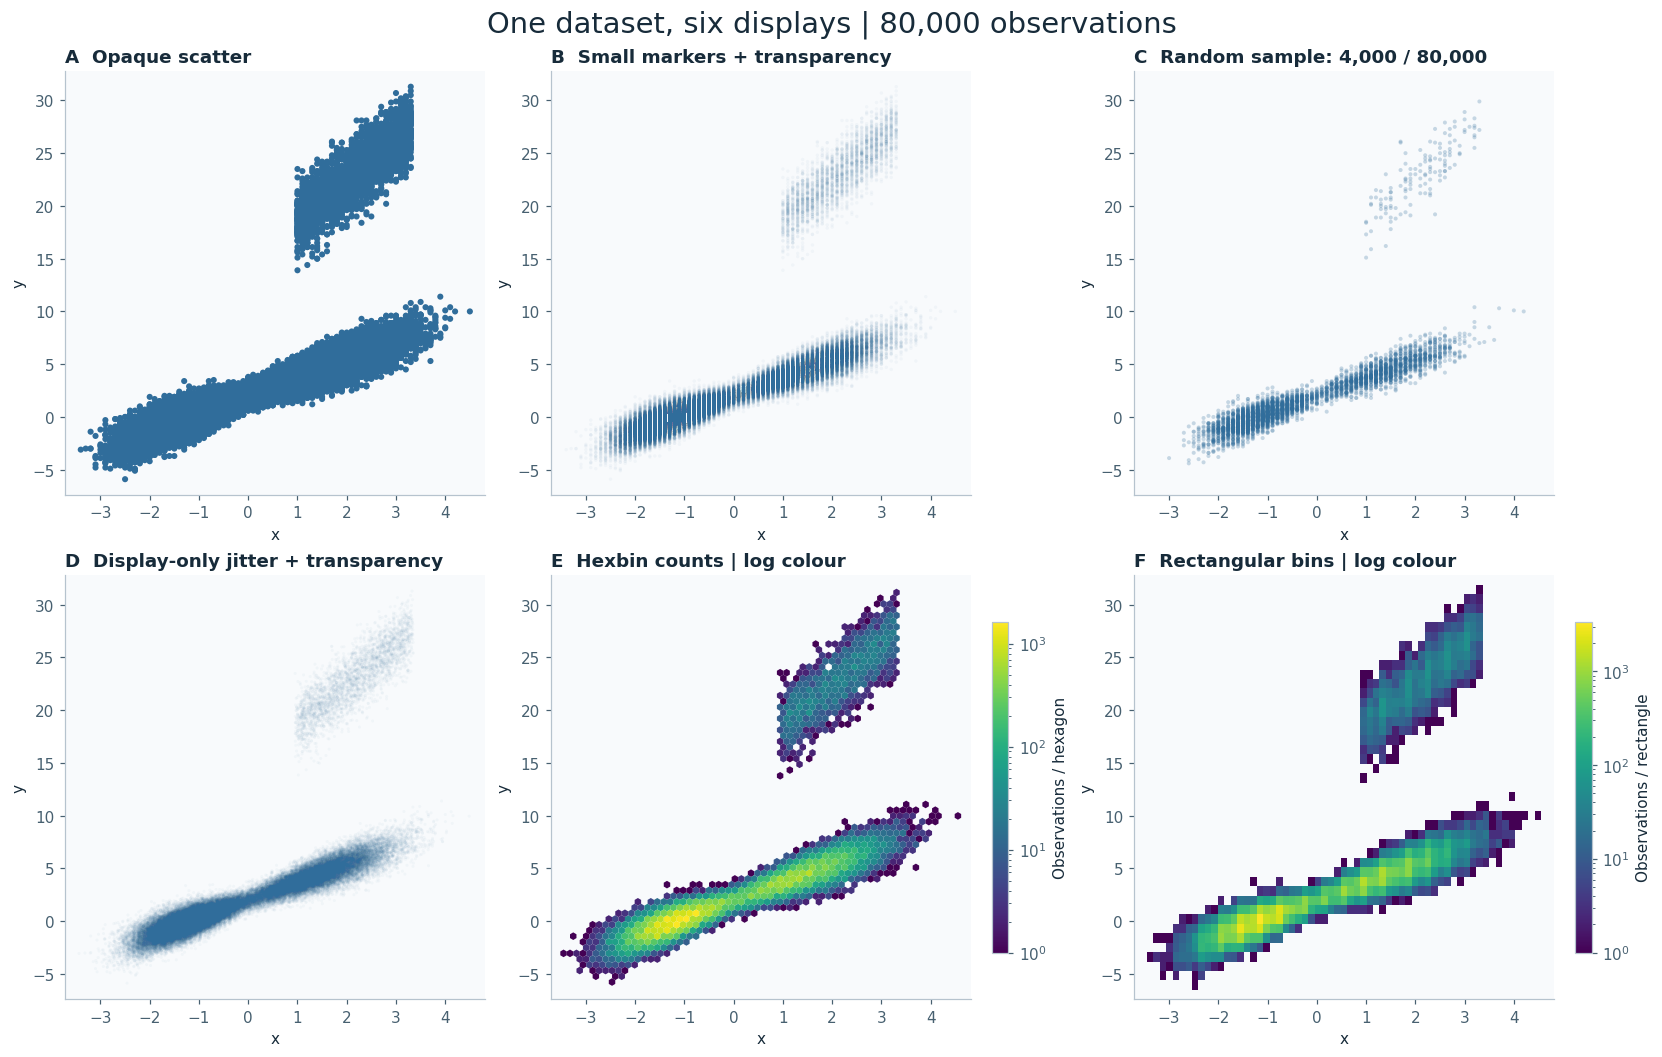

In [3]:
def padded_limits(values, fraction=0.04):
    lo, hi = np.min(values), np.max(values)
    pad = (hi - lo) * fraction if hi > lo else max(abs(lo) * fraction, 1.0)
    return (lo - pad, hi + pad)

XLIM, YLIM = padded_limits(x), padded_limits(y)
EXTENT = (*XLIM, *YLIM)
SAMPLE_N = min(4_000, len(data))
sample_idx = np.random.default_rng(SEED + 1).choice(len(data), SAMPLE_N, replace=False)

# For a CSV, set these to the actual x/y measurement steps, or leave them at zero.
JITTER_X_STEP = ROUNDING_STEP if IS_SYNTHETIC else 0.0
JITTER_Y_STEP = ROUNDING_STEP if IS_SYNTHETIC else 0.0
jitter_rng = np.random.default_rng(SEED + 2)
x_display = x + jitter_rng.uniform(-JITTER_X_STEP / 2, JITTER_X_STEP / 2, len(x))
y_display = y + jitter_rng.uniform(-JITTER_Y_STEP / 2, JITTER_Y_STEP / 2, len(y))

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5), layout="constrained")
fig.suptitle(f"One dataset, six displays | {len(data):,} observations", fontsize=19)
flat = axes.ravel()
flat[0].scatter(x, y, s=16, c=BLUE, edgecolors="none", rasterized=True)
flat[0].set_title("A  Opaque scatter", loc="left")
flat[1].scatter(x, y, s=5, alpha=0.04, c=BLUE, edgecolors="none", rasterized=True)
flat[1].set_title("B  Small markers + transparency", loc="left")
flat[2].scatter(x[sample_idx], y[sample_idx], s=7, alpha=0.25,
                c=BLUE, edgecolors="none", rasterized=True)
flat[2].set_title(f"C  Random sample: {SAMPLE_N:,} / {len(data):,}", loc="left")
flat[3].scatter(x_display, y_display, s=4, alpha=0.035,
                c=BLUE, edgecolors="none", rasterized=True)
flat[3].set_title("D  Display-only jitter + transparency" if
                  JITTER_X_STEP or JITTER_Y_STEP else "D  Jitter disabled: unknown resolution",
                  loc="left")
hb = flat[4].hexbin(x, y, gridsize=65, extent=EXTENT, mincnt=1,
                    norm=LogNorm(), cmap="viridis", linewidths=0, rasterized=True)
flat[4].set_title("E  Hexbin counts | log colour", loc="left")
rect_counts, x_edges, y_edges, mesh = flat[5].hist2d(
    x, y, bins=(65, 45), range=[XLIM, YLIM], norm=LogNorm(), cmap="viridis",
    rasterized=True)
flat[5].set_title("F  Rectangular bins | log colour", loc="left")
for ax in flat:
    ax.set(xlim=XLIM, ylim=YLIM, xlabel=X_LABEL, ylabel=Y_LABEL)
fig.colorbar(hb, ax=flat[4], label="Observations / hexagon", shrink=0.78)
fig.colorbar(mesh, ax=flat[5], label="Observations / rectangle", shrink=0.78)
show_and_save(fig, "01_six_displays")

### Choose a bin size, then check that the story survives changing it

Coarse bins reveal the broad distribution; very fine bins expose the rounding lattice and
become sparse. There is no universally optimal grid size. Try a few at the intended figure
size and choose one that preserves the structure you care about.

The following panels share one count colour scale. Smaller bins cover less area and
consequently tend to contain fewer points. Colours represent **counts per bin**, not a
probability density per unit area; matching colours across these grids does not imply
matching density. Keep the same edges/extent and colour normalization when comparing
groups. If group sizes differ and you want distribution shape, normalize by group size
and bin area instead of comparing raw counts.

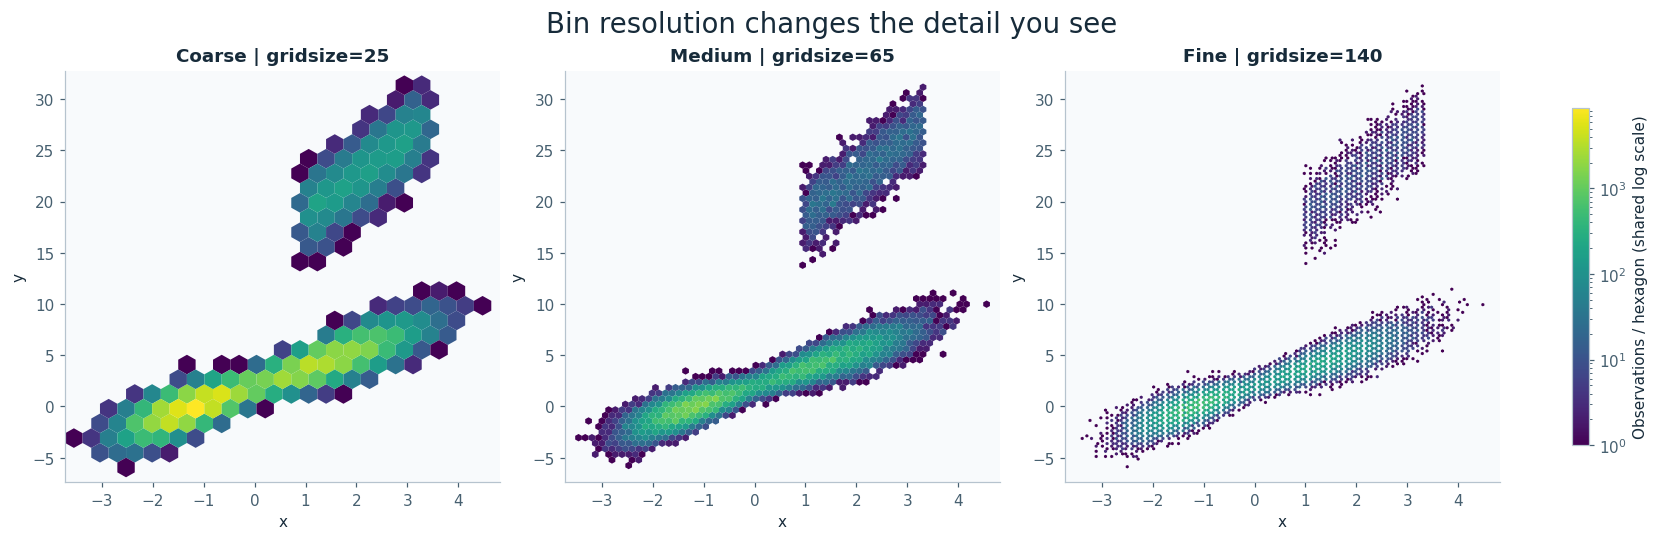

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), layout="constrained")
fig.suptitle("Bin resolution changes the detail you see", fontsize=18)
artists = []
for ax, grid, label in zip(axes, [25, 65, 140], ["Coarse", "Medium", "Fine"]):
    artist = ax.hexbin(x, y, gridsize=grid, extent=EXTENT, mincnt=1,
                       cmap="viridis", linewidths=0, rasterized=True)
    artists.append(artist)
    ax.set(title=f"{label} | gridsize={grid}", xlim=XLIM, ylim=YLIM,
           xlabel=X_LABEL, ylabel=Y_LABEL)
count_norm = LogNorm(vmin=1, vmax=max(2, max(a.get_array().max() for a in artists)))
for artist in artists:
    artist.set_norm(count_norm)
fig.colorbar(artists[0], ax=axes, label="Observations / hexagon (shared log scale)", shrink=0.82)
show_and_save(fig, "02_bin_resolution")

## 3. Add trend lines: ordinary and robust linear regression

Both fits use the same model, $\hat y=\beta_0+\beta_1x$, and **every valid original row**.
Never fit to jittered points, unweighted bin centres, or just the display sample.

**OLS** minimizes $\sum_i (y_i-\hat y_i)^2$. Large residuals have strong influence.
It estimates a conditional mean when that mean is correctly specified as linear.

**Huber regression** minimizes a loss that is quadratic for small standardized residuals
and linear in their magnitude beyond a threshold. Here we use statsmodels `RLM` with
`HuberT(t=1.345)` and a median-absolute-deviation residual scale. It repeatedly reduces
the weights of large residuals; it does not delete them. This follows the
[statsmodels robust-model example](https://www.statsmodels.org/stable/examples/notebooks/generated/robust_models_0.html)
and [HuberT definition](https://www.statsmodels.org/stable/generated/statsmodels.robust.norms.HuberT.html).

**Interpretation:** Huber estimates a robust centre, not generally the conditional mean
or median under asymmetric errors. It can still be sensitive to extreme x values
(high leverage). Compare methods and investigate why they differ.
See the [robust-regression comparison](https://scikit-learn.org/stable/modules/linear_model.html#robustness-regression-outliers-and-modeling-errors).

Robust regression changes the fitted coefficients. OLS with heteroskedasticity-robust
standard errors changes uncertainty estimates, not the OLS line. We show fitted trends
here, without confidence or prediction bands.

In [5]:
def fit_lines(frame):
    design = sm.add_constant(frame[["x"]], has_constant="add")
    ordinary = sm.OLS(frame["y"], design).fit()
    robust = sm.RLM(frame["y"], design, M=sm.robust.norms.HuberT(t=1.345)).fit(
        scale_est="mad", maxiter=200, tol=1e-8)
    if robust.fit_history["iteration"] >= 200:
        warnings.warn("Huber reached the iteration limit; inspect convergence before interpreting.")
    return ordinary, robust

ols, huber = fit_lines(data)
x_grid = np.linspace(x.min(), x.max(), 400)  # sorted and within observed support
grid_design = sm.add_constant(pd.DataFrame({"x": x_grid}), has_constant="add")
ols_line, huber_line = ols.predict(grid_design), huber.predict(grid_design)

rows = []
for name, fit in [("OLS", ols), ("Huber", huber)]:
    residuals = y - fit.fittedvalues
    rows.append({"method": name, "intercept": fit.params["const"],
                 "slope": fit.params["x"], "rows fitted": int(fit.nobs),
                 "training RMSE": np.sqrt(np.mean(residuals ** 2)),
                 "training median |residual|": np.median(np.abs(residuals))})
model_comparison = pd.DataFrame(rows).set_index("method")
display(model_comparison.round(4))
print(f"Huber iterations: {huber.fit_history['iteration']}; residual scale: {huber.scale:.3f}")
if IS_SYNTHETIC:
    print("Known latent main-population line, before rounding: intercept=2.0, slope=1.7")

,intercept,slope,rows fitted,training RMSE,training median |residual|
method,,,,,
OLS,2.8181,2.4973,80000,3.2993,0.9263
Huber,2.0733,1.7711,80000,3.5161,0.5098


Huber iterations: 20; residual scale: 0.756
Known latent main-population line, before rounding: intercept=2.0, slope=1.7


OLS has the lowest training RMSE for this linear model by construction; that alone does
not make it the most useful summary of the main population. The median absolute residual
emphasizes a typical error. These are descriptive training metrics, not validation scores.
For a prediction task, evaluate on held-out observations using a metric that matches the goal.

The next figure keeps the full data range on the left. The right panel zooms to the central
1st–95th percentile rectangle; its title reports the excluded observations. It reuses the
**same bins, colour scale, and fits** as the full-range panel. Zooming changes the view only.

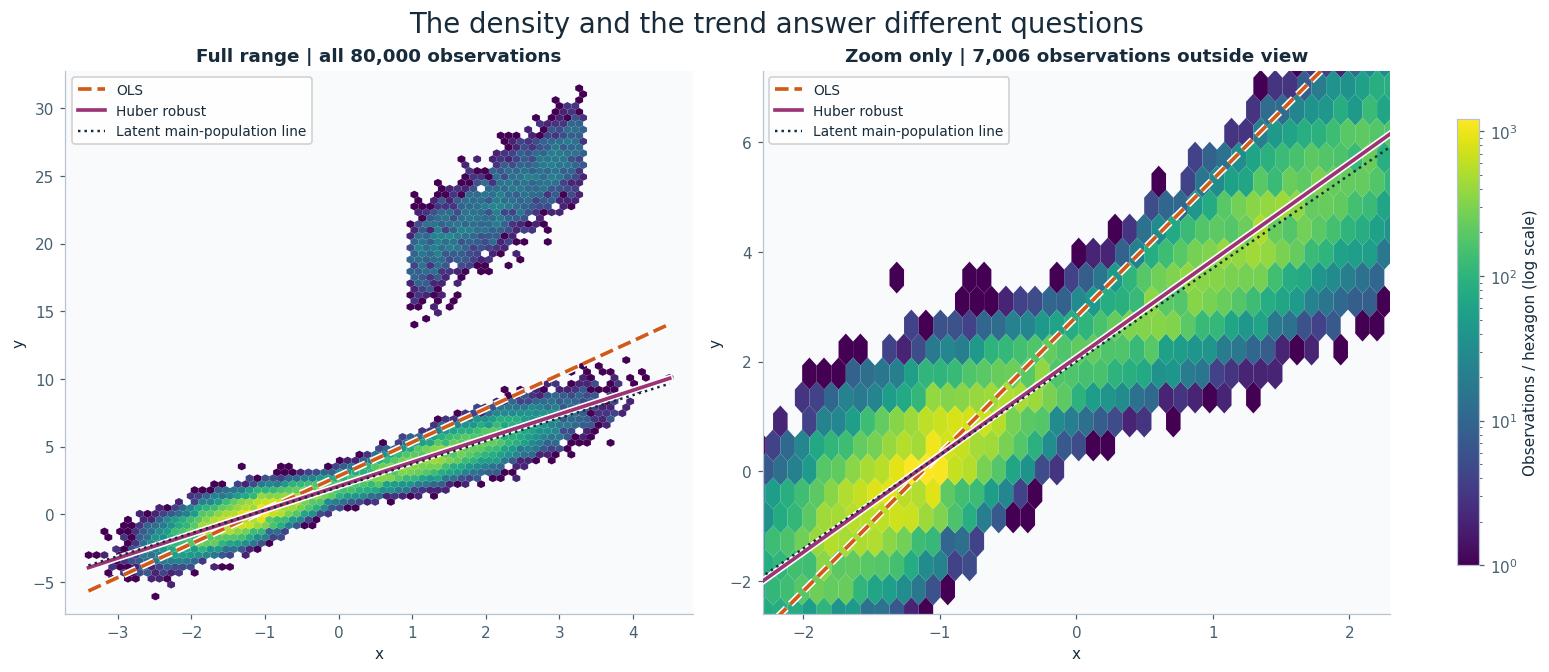

In [6]:
def overlay_lines(ax, grid=x_grid, ordinary_line=ols_line, robust_line=huber_line,
                  include_truth=IS_SYNTHETIC):
    halo = [pe.Stroke(linewidth=4.5, foreground="white"), pe.Normal()]
    ax.plot(grid, ordinary_line, color=ORANGE, lw=2.4, ls="--",
            label="OLS", path_effects=halo, zorder=5)
    ax.plot(grid, robust_line, color=MAGENTA, lw=2.4,
            label="Huber robust", path_effects=halo, zorder=6)
    if include_truth:
        ax.plot(grid, 2 + 1.7 * grid, color=INK, lw=1.6, ls=":",
                label="Latent main-population line", zorder=7)
    ax.legend(loc="upper left", fontsize=9)

zoom_x = np.quantile(x, [0.01, 0.95])
zoom_y = np.quantile(y, [0.01, 0.95])
if zoom_x[0] == zoom_x[1]:
    zoom_x = XLIM
if zoom_y[0] == zoom_y[1]:
    zoom_y = YLIM
in_zoom = ((x >= zoom_x[0]) & (x <= zoom_x[1]) &
           (y >= zoom_y[0]) & (y <= zoom_y[1]))
fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
fig.suptitle("The density and the trend answer different questions", fontsize=18)
hbs = []
for ax in axes:
    hbs.append(ax.hexbin(x, y, gridsize=80, extent=EXTENT, mincnt=1,
                        cmap="viridis", linewidths=0, rasterized=True))
    overlay_lines(ax)
    ax.set(xlabel=X_LABEL, ylabel=Y_LABEL)
fit_norm = LogNorm(vmin=1, vmax=max(2, hbs[0].get_array().max()))
for artist in hbs:
    artist.set_norm(fit_norm)
axes[0].set(xlim=XLIM, ylim=YLIM, title=f"Full range | all {len(data):,} observations")
axes[1].set(xlim=zoom_x, ylim=zoom_y,
            title=f"Zoom only | {(~in_zoom).sum():,} observations outside view")
fig.colorbar(hbs[0], ax=axes, label="Observations / hexagon (log scale)", shrink=0.82)
fig.savefig(FIGURE_DIR / "03_ols_vs_huber.svg", dpi=180, bbox_inches="tight")
show_and_save(fig, "03_ols_vs_huber")

In [7]:
if IS_SYNTHETIC:
    display(Markdown(
        f"**This run:** OLS slope **{ols.params['x']:.3f}**, Huber slope "
        f"**{huber.params['x']:.3f}**, latent main-population slope **1.700**. "
        "The deliberately shifted group pulls the OLS line upward at positive x. "
        "Huber reduces the influence of its large residuals. Neither method knows "
        "the synthetic group labels; all rows enter both fits."
    ))
else:
    display(Markdown(
        f"**Your data:** OLS slope **{ols.params['x']:.3f}**, "
        f"Huber slope **{huber.params['x']:.3f}**. "
        "A disagreement is a reason to inspect residuals, leverage, and subgroups."
    ))

**This run:** OLS slope **2.497**, Huber slope **1.771**, latent main-population slope **1.700**. The deliberately shifted group pulls the OLS line upward at positive x. Huber reduces the influence of its large residuals. Neither method knows the synthetic group labels; all rows enter both fits.

## 4. Check the fit, not just the line

Residual density plots reveal curvature, changing spread, and unusual groups without
hiding overlapping residuals. The colour scale is shared across the two models.

A straight band near zero supports a linear centre. Curvature suggests a misspecified
trend; a widening band suggests changing variance. Neither issue is automatically fixed
by robust regression.

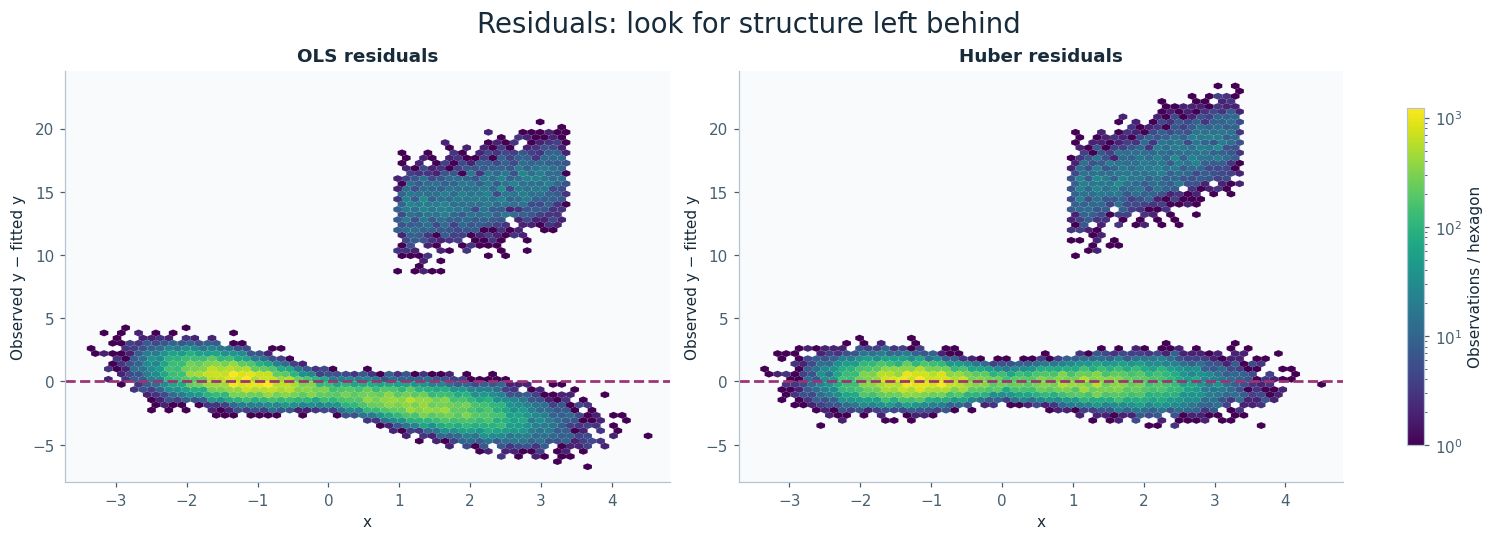

In [8]:
residual_arrays = [np.asarray(ols.resid), np.asarray(huber.resid)]
RESID_LIM = padded_limits(np.concatenate(residual_arrays))
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), layout="constrained")
fig.suptitle("Residuals: look for structure left behind", fontsize=18)
residual_artists = []
for ax, residual, title in zip(axes, residual_arrays, ["OLS residuals", "Huber residuals"]):
    residual_artists.append(ax.hexbin(
        x, residual, gridsize=70, extent=(*XLIM, *RESID_LIM), mincnt=1,
        cmap="viridis", linewidths=0, rasterized=True))
    ax.axhline(0, color=MAGENTA, lw=1.8, ls="--")
    ax.set(title=title, xlabel=X_LABEL, ylabel="Observed y − fitted y",
           xlim=XLIM, ylim=RESID_LIM)
residual_norm = LogNorm(vmin=1, vmax=max(2, max(a.get_array().max() for a in residual_artists)))
for artist in residual_artists:
    artist.set_norm(residual_norm)
fig.colorbar(residual_artists[0], ax=axes, label="Observations / hexagon", shrink=0.82)
show_and_save(fig, "04_residuals")

### What does Huber downweight?

Let $u=(y-\hat y)/\hat s$ be the residual divided by the robust residual scale.
Huber's weight is $1$ for $|u|\leq t$ and $t/|u|$ otherwise, with $t=1.345$ here.
Large-residual points keep positive weights. A weight below one is **not** a definitive
outlier label; even ordinary observations in the tails get downweighted.
[Huber weights](https://www.statsmodels.org/stable/generated/statsmodels.robust.norms.HuberT.weights.html)

The curve shows the rule, and the histogram shows weights across all fitted rows.
In the default example, points in the shifted group receive very small weights.

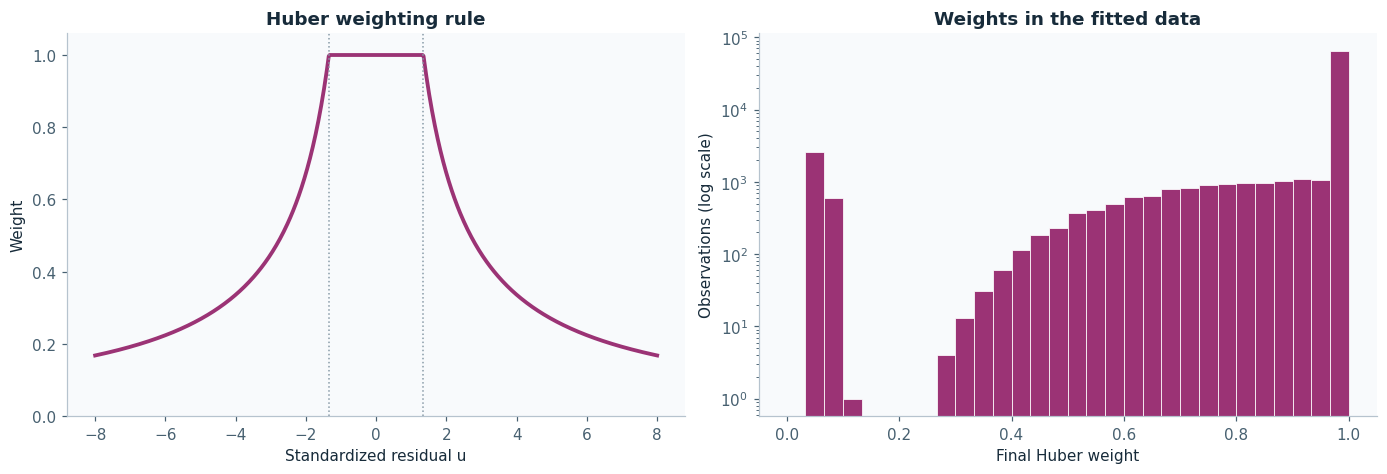

4.8% of rows have a Huber weight below 0.5.


In [9]:
u = np.linspace(-8, 8, 600)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), layout="constrained")
axes[0].plot(u, sm.robust.norms.HuberT(t=1.345).weights(u), color=MAGENTA, lw=2.5)
axes[0].axvline(-1.345, color="#899ba8", lw=1, ls=":")
axes[0].axvline(1.345, color="#899ba8", lw=1, ls=":")
axes[0].set(title="Huber weighting rule", xlabel="Standardized residual u",
            ylabel="Weight", ylim=(0, 1.06))
axes[1].hist(huber.weights, bins=np.linspace(0, 1.000001, 31), color=MAGENTA,
             edgecolor="white", linewidth=0.5)
axes[1].set(title="Weights in the fitted data", xlabel="Final Huber weight",
            ylabel="Observations (log scale)", yscale="log")
show_and_save(fig, "05_huber_weights")
print(f"{np.mean(np.asarray(huber.weights) < 0.5):.1%} of rows have a Huber weight below 0.5.")

## 5. A descriptive trend check: binned medians

Divide x into up to 24 quantile bins, which tend to have similar numbers of observations
(ties can make the counts uneven). Plot each bin's median x and median y, plus its
25th–75th percentile interval. This summarizes the conditional distribution locally
without assuming one straight line. It can reveal patterns that a single coefficient misses.

The shaded interval is the **spread of y observations within each x bin**, not a confidence
interval for a fitted trend. Binned medians are descriptive and are not used to fit OLS or
Huber. Counts remain in the table so sparsely populated bins can be identified.

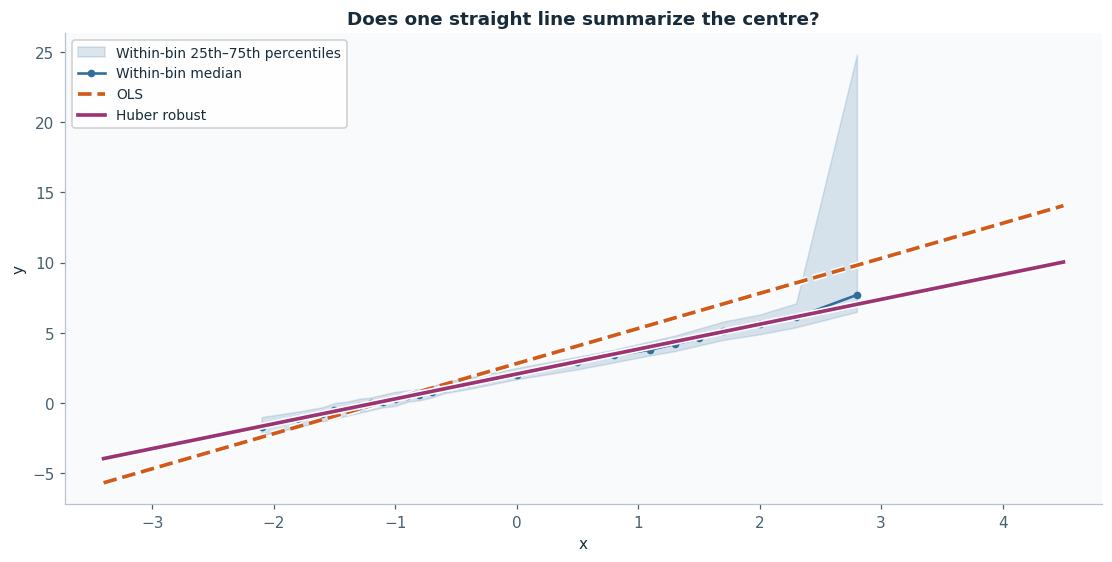

,x_mid,y_median,y_q25,y_q75,count
0,-2.1,-1.7,-2.3,-1.0,3623
1,-1.8,-1.1,-1.7,-0.6,3318
2,-1.6,-0.8,-1.3,-0.3,5096
3,-1.5,-0.5,-1.1,0.0,3128
4,-1.4,-0.4,-0.9,0.1,3331
5,-1.3,-0.2,-0.7,0.3,3584
6,-1.2,0.0,-0.5,0.4,3660
7,-1.1,0.1,-0.3,0.6,3628


Bin counts range from 2,271 to 5,096.


In [10]:
bins = pd.qcut(data["x"], q=min(24, data["x"].nunique()), duplicates="drop")
binned = data.assign(x_bin=bins).groupby("x_bin", observed=True).agg(
    x_mid=("x", "median"), y_median=("y", "median"),
    y_q25=("y", lambda s: s.quantile(0.25)),
    y_q75=("y", lambda s: s.quantile(0.75)), count=("y", "size"),
).sort_values("x_mid")
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.fill_between(binned.x_mid, binned.y_q25, binned.y_q75,
                 color=BLUE, alpha=0.17, label="Within-bin 25th–75th percentiles")
ax.plot(binned.x_mid, binned.y_median, "o-", color=BLUE, markersize=4,
         lw=1.7, label="Within-bin median")
overlay_lines(ax, include_truth=False)
ax.set(title="Does one straight line summarize the centre?",
       xlabel=X_LABEL, ylabel=Y_LABEL, xlim=XLIM)
ax.legend(loc="best", fontsize=9)
show_and_save(fig, "06_binned_summary")
display(binned.reset_index(drop=True).round(3).head(8))
print(f"Bin counts range from {binned['count'].min():,} to {binned['count'].max():,}.")

## 6. If the trend bends: LOWESS with and without robust reweighting

A robust straight line is still a straight line. This **separate synthetic example** has
a curved trend and upward contamination, so we use local linear fits:

- `it=0`: LOWESS with distance weights, without robust residual reweighting.
- `it=3`: LOWESS with three residual reweighting iterations using bisquare weights.

Both use `frac=0.22`: each local fit considers roughly 22% of the observations. This
bandwidth controls smoothness; check several values before interpreting small bends.
Robust LOWESS is a different estimator from the Huber model above. See the
[statsmodels LOWESS documentation](https://www.statsmodels.org/stable/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html).

LOWESS can be expensive on large data. The example has only 4,000 points.
For larger datasets, `delta` can speed it up using interpolation between nearby fits;
any sample used to fit a smoother should be disclosed separately from a display sample.

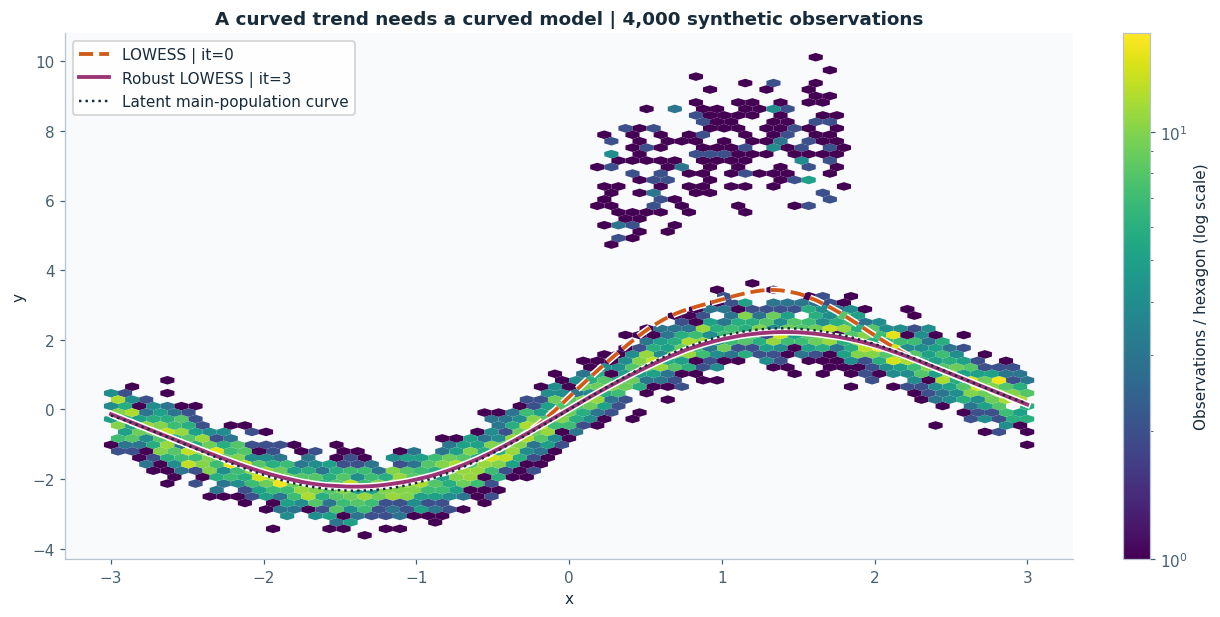

In [11]:
curved_rng = np.random.default_rng(SEED + 3)
curved_x = np.sort(curved_rng.uniform(-3, 3, 4_000))
curved_truth = 0.4 * curved_x + 1.8 * np.sin(1.25 * curved_x)
curved_y = curved_truth + curved_rng.normal(0, 0.45, len(curved_x))
shifted = ((curved_x > 0.2) & (curved_x < 1.8) &
           (curved_rng.random(len(curved_x)) < 0.22))
curved_y[shifted] += curved_rng.uniform(4, 7, shifted.sum())
curved_grid = np.linspace(curved_x.min(), curved_x.max(), 300)
smooth_plain = lowess(curved_y, curved_x, frac=0.22, it=0,
                      xvals=curved_grid, is_sorted=True)
smooth_robust = lowess(curved_y, curved_x, frac=0.22, it=3,
                       xvals=curved_grid, is_sorted=True)

fig, ax = plt.subplots(figsize=(11, 5.5), layout="constrained")
curved_hb = ax.hexbin(curved_x, curved_y, gridsize=65, mincnt=1,
                      norm=LogNorm(), cmap="viridis", linewidths=0, rasterized=True)
halo = [pe.Stroke(linewidth=4.5, foreground="white"), pe.Normal()]
ax.plot(curved_grid, smooth_plain, color=ORANGE, ls="--", lw=2.5,
         label="LOWESS | it=0", path_effects=halo)
ax.plot(curved_grid, smooth_robust, color=MAGENTA, lw=2.5,
         label="Robust LOWESS | it=3", path_effects=halo)
ax.plot(curved_x, curved_truth, color=INK, ls=":", lw=1.6,
         label="Latent main-population curve")
ax.set(title="A curved trend needs a curved model | 4,000 synthetic observations",
       xlabel="x", ylabel="y")
ax.legend(loc="upper left")
fig.colorbar(curved_hb, ax=ax, label="Observations / hexagon (log scale)")
show_and_save(fig, "07_lowess")

## 7. A reusable recipe for your own data

This helper combines the recommended display and the two linear fits. It uses the data
cleaning and fitting helpers defined earlier, returns both fitted models, and fits all
valid observations. The prediction grid is sorted and restricted to the observed x range.

Use `plot_dense_with_trends(my_dataframe, "my_x", "my_y")`. For a nonlinear relationship,
use a suitable curve instead, following the preceding example.

Kept 80,000 / 80,000 rows; excluded 0 invalid pairs.


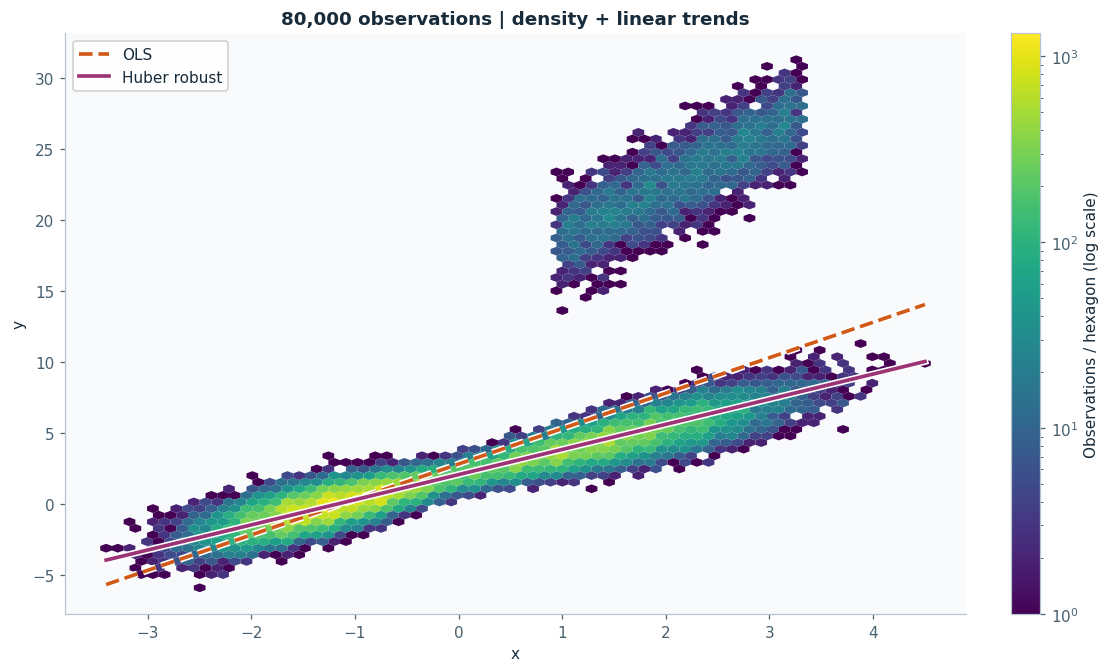

In [12]:
def plot_dense_with_trends(frame, x_col="x", y_col="y", gridsize=70):
    clean = clean_xy(frame, x_col, y_col)
    ordinary, robust = fit_lines(clean)
    grid = np.linspace(clean.x.min(), clean.x.max(), 400)
    design = sm.add_constant(pd.DataFrame({"x": grid}), has_constant="add")
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
    counts = ax.hexbin(clean.x, clean.y, gridsize=gridsize, mincnt=1,
                       norm=LogNorm(), cmap="viridis", linewidths=0, rasterized=True)
    halo = [pe.Stroke(linewidth=4.5, foreground="white"), pe.Normal()]
    ax.plot(grid, ordinary.predict(design), "--", color=ORANGE, lw=2.4,
             label="OLS", path_effects=halo)
    ax.plot(grid, robust.predict(design), color=MAGENTA, lw=2.4,
             label="Huber robust", path_effects=halo)
    ax.set(title=f"{len(clean):,} observations | density + linear trends",
           xlabel=x_col, ylabel=y_col)
    ax.legend(loc="upper left")
    fig.colorbar(counts, ax=ax, label="Observations / hexagon (log scale)")
    return fig, ax, {"ols": ordinary, "huber": robust, "data": clean}

recipe_fig, recipe_ax, recipe_results = plot_dense_with_trends(data)
show_and_save(recipe_fig, "08_reusable_recipe")

## 8. Ten more views: choose the question before the chart

These charts extend the basic scatter/hexbin comparison. Most reuse the main dataset
and its **full-data OLS and Huber fits**. The final faceting example uses a separate
dataset with known group labels. Some views preserve individual x–y locations;
others deliberately summarize the distribution within ranges of x.

| Option | Best question | Watch for |
|:--|:--|:--|
| Duplicate-count bubbles | How often does exactly this pair occur? | Overlapping bubbles and hard-to-see singletons |
| Density-coloured scatter | Where are the crowded points? | Bin resolution and drawing order |
| KDE contours | What is the smooth shape of the cloud? | Bandwidth and rare groups outside the contours |
| Joint plot + marginals | Where do x and y concentrate individually? | Marginals alone cannot describe association |
| Conditional heatmap | At this x, which y values are common? | Sparse x bins can look too important |
| Quantile fan | How do the centre and tails change with x? | Observation spread is not uncertainty in a fit |
| Binned boxplots | How do medians and quartiles change? | Multimodality and hidden tails |
| Binned violins | Is y multimodal within an x range? | Smoothing and width normalization |
| Ridgelines | How does the full y distribution shift across x ranges? | Ridge scaling and bin choice |
| Small multiples / facets | Do meaningful groups have different relationships? | Pooled and within-group trends can disagree |

### 8.1–8.2. Keep the dots: bubbles and density colour

**Count bubbles** draw one marker per *exact* coordinate pair, with marker area
proportional to its number of observations. This is useful for genuinely rounded or
discrete measurements. Do not round continuous data merely to create bubbles without
disclosing the rounding. Large counts also get brighter colours here. Singletons have
very small markers; large bubbles can overlap.

**Density-coloured scatter** keeps all original points and colours each by the count
in its rectangular neighbourhood bin. It is a binned crowding estimate, not a KDE.
Drawing sparse points first and dense points last keeps high-density areas visible;
the result still depends on marker size, bin size, and drawing order. The colourbar
labels make the two different count definitions explicit. Both trend fits remain unchanged.

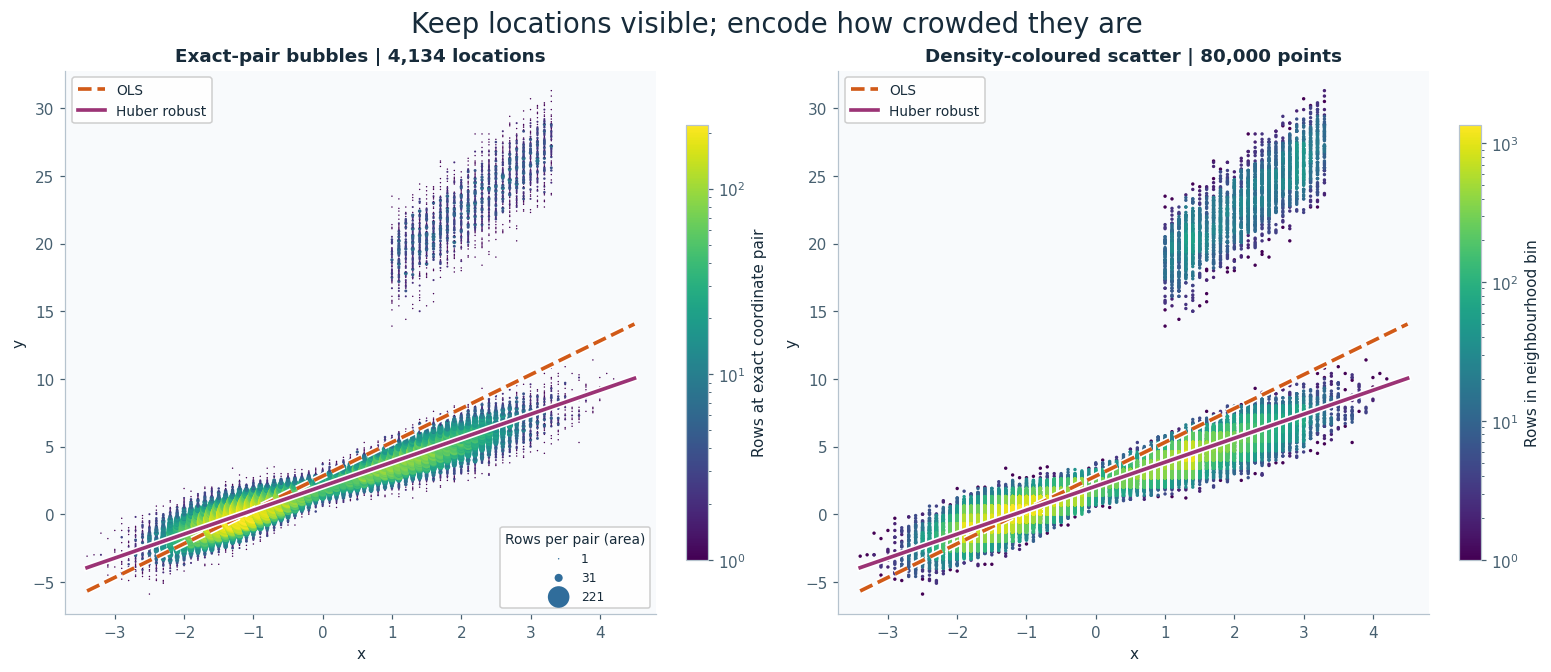

In [13]:
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter1d
from matplotlib.ticker import PercentFormatter

exact_counts = data.groupby(["x", "y"], as_index=False).size().rename(columns={"size": "count"})
extra_counts, extra_x_edges, extra_y_edges = np.histogram2d(
    x, y, bins=(80, 60), range=[XLIM, YLIM])
ix = np.clip(np.searchsorted(extra_x_edges, x, side="right") - 1, 0, extra_counts.shape[0] - 1)
iy = np.clip(np.searchsorted(extra_y_edges, y, side="right") - 1, 0, extra_counts.shape[1] - 1)
local_count = extra_counts[ix, iy]
draw_order = np.argsort(local_count, kind="stable")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
fig.suptitle("Keep locations visible; encode how crowded they are", fontsize=18)
area_per_row = 200 / exact_counts["count"].max()
bubbles = axes[0].scatter(
    exact_counts.x, exact_counts.y, s=area_per_row * exact_counts["count"],
    c=exact_counts["count"], cmap="viridis",
    norm=LogNorm(vmin=1, vmax=max(2, exact_counts["count"].max())),
    edgecolors="none", rasterized=True)
density_dots = axes[1].scatter(
    x[draw_order], y[draw_order], s=5, c=local_count[draw_order],
    cmap="viridis", norm=LogNorm(vmin=1, vmax=max(2, local_count.max())),
    edgecolors="none", rasterized=True)
for ax in axes:
    overlay_lines(ax, include_truth=False)
    ax.set(xlim=XLIM, ylim=YLIM, xlabel=X_LABEL, ylabel=Y_LABEL)
axes[0].set_title(f"Exact-pair bubbles | {len(exact_counts):,} locations")
axes[1].set_title(f"Density-coloured scatter | {len(data):,} points")
line_legend = axes[0].get_legend()
axes[0].add_artist(line_legend)
size_values = np.unique(np.quantile(exact_counts["count"], [0, 0.8, 1]).astype(int))
size_handles = [axes[0].scatter([], [], s=area_per_row * v, color=BLUE,
                               edgecolors="none", label=f"{v:,}") for v in size_values]
axes[0].legend(handles=size_handles, title="Rows per pair (area)",
               loc="lower right", fontsize=8, title_fontsize=9)
fig.colorbar(bubbles, ax=axes[0], label="Rows at exact coordinate pair", shrink=0.8)
fig.colorbar(density_dots, ax=axes[1], label="Rows in neighbourhood bin", shrink=0.8)
show_and_save(fig, "09_bubbles_and_density_scatter")

### 8.3. Filled density contours: reveal the shape of the cloud

A two-dimensional Gaussian KDE estimates a smooth joint density. Here it is fitted
to a reproducible sample of up to 6,000 rows for speed, **including repeated rows**.
The faint dots show that sample too; regression overlays still use the full dataset.

Compare bandwidths at 0.65 and 1.15 times Scott's rule. Narrower smoothing exposes more
detail; wider smoothing can merge peaks and imply density in gaps. A KDE can also extend
beyond observed or physically possible boundaries. These choices are covered in
[SciPy's gaussian_kde documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html).

The nested filled regions contain approximately **50%, 80%, and 95% of the estimated
KDE mass inside the plotted window**. We compute them from a grid, normalizing within
that window; these are not exact fractions of observed points, confidence regions,
or probability statements about the regression line. Rare groups can fall outside
even the outer region, which is why the faint sample remains visible.
If a contour level forms several separate islands, its percentage refers to their
combined region, not to each island individually.

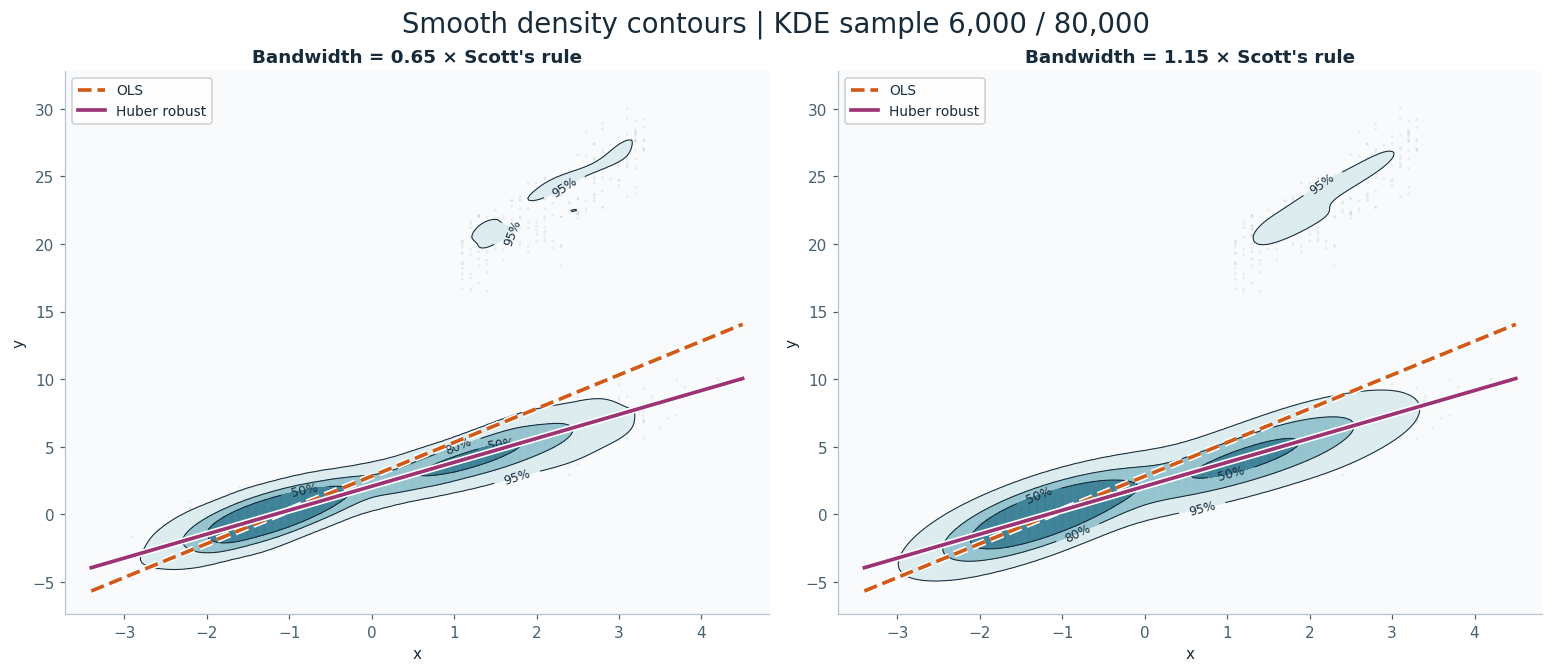

In [14]:
KDE_N = min(6_000, len(data))
kde_idx = np.random.default_rng(SEED + 10).choice(len(data), KDE_N, replace=False)
kde_points = np.vstack([x[kde_idx], y[kde_idx]])
if np.linalg.matrix_rank(kde_points - kde_points.mean(axis=1, keepdims=True)) < 2:
    print("2D KDE skipped: the sample lies on a line, so its covariance is singular.")
else:
    kde_gx = np.linspace(*XLIM, 180)
    kde_gy = np.linspace(*YLIM, 180)
    kde_xx, kde_yy = np.meshgrid(kde_gx, kde_gy)
    kde_query = np.vstack([kde_xx.ravel(), kde_yy.ravel()])
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
    fig.suptitle(f"Smooth density contours | KDE sample {KDE_N:,} / {len(data):,}", fontsize=18)
    for ax, multiplier in zip(axes, [0.65, 1.15]):
        kde = gaussian_kde(kde_points, bw_method=lambda k: multiplier * k.scotts_factor())
        density = kde(kde_query).reshape(kde_xx.shape)
        descending = np.sort(density.ravel())[::-1]
        cumulative_mass = np.cumsum(descending) / descending.sum()
        thresholds = [descending[np.searchsorted(cumulative_mass, mass)] for mass in [0.95, 0.8, 0.5]]
        levels = np.unique(thresholds)
        ax.scatter(x[kde_idx], y[kde_idx], s=3, c="#9aa9b4", alpha=0.18,
                   edgecolors="none", rasterized=True)
        ax.contourf(kde_xx, kde_yy, density,
                    levels=np.r_[levels, density.max() * (1 + 1e-8)],
                    colors=["#dbecef", "#92c2cd", "#387f95"], alpha=0.95)
        contours = ax.contour(kde_xx, kde_yy, density, levels=levels,
                              colors=INK, linewidths=0.7)
        ax.clabel(contours, fmt={v: f"{m:.0%}" for v, m in zip(thresholds, [0.95, 0.8, 0.5])},
                  fontsize=8, inline=True)
        overlay_lines(ax, include_truth=False)
        ax.set(title=f"Bandwidth = {multiplier:.2f} × Scott's rule",
               xlim=XLIM, ylim=YLIM, xlabel=X_LABEL, ylabel=Y_LABEL)
    show_and_save(fig, "10_density_contours")

### 8.4. Joint plot with marginal histograms

Put the joint x–y density in the centre and the one-dimensional distributions alongside
it. This makes uneven sampling along x, multiple x populations, and a long y tail easy
to see in one figure. All three displays use all valid rows. The side histograms show
counts on linear axes; the main panel uses logarithmic count colour.

Marginals describe each variable separately; the central plot is still needed to see
how they relate. The layout follows
[Matplotlib's marginal histogram example](https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_hist.html).

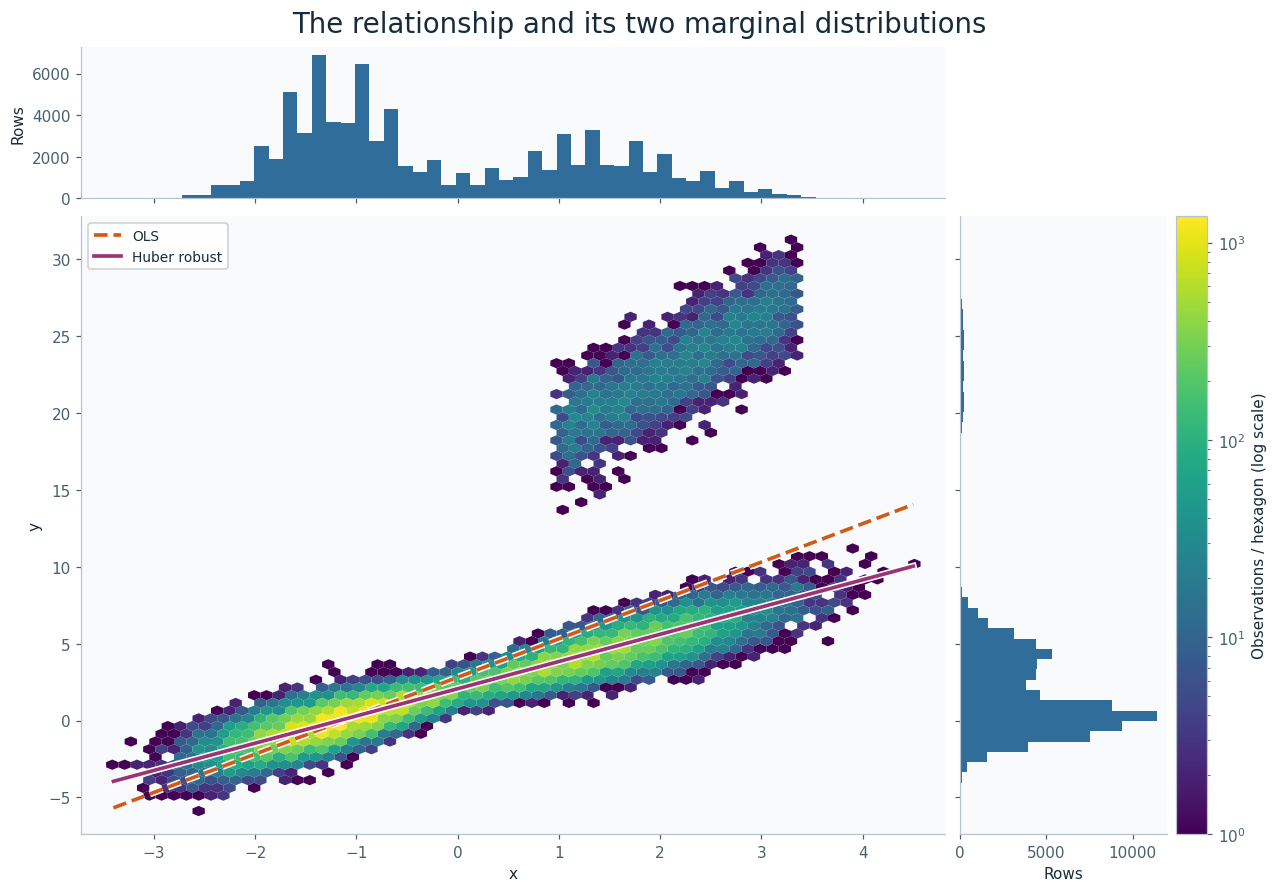

In [15]:
fig = plt.figure(figsize=(11.5, 8), layout="constrained")
gs = fig.add_gridspec(2, 3, width_ratios=[5, 1.2, 0.18], height_ratios=[1.1, 4.5])
joint_ax = fig.add_subplot(gs[1, 0])
top_ax = fig.add_subplot(gs[0, 0], sharex=joint_ax)
right_ax = fig.add_subplot(gs[1, 1], sharey=joint_ax)
cbar_ax = fig.add_subplot(gs[1, 2])
joint_hex = joint_ax.hexbin(x, y, gridsize=70, extent=EXTENT, mincnt=1,
                            norm=LogNorm(), cmap="viridis", linewidths=0, rasterized=True)
overlay_lines(joint_ax, include_truth=False)
top_ax.hist(x, bins=60, range=XLIM, color=BLUE, edgecolor="none")
right_ax.hist(y, bins=60, range=YLIM, orientation="horizontal", color=BLUE, edgecolor="none")
top_ax.tick_params(labelbottom=False)
right_ax.tick_params(labelleft=False)
top_ax.set_ylabel("Rows")
right_ax.set_xlabel("Rows")
joint_ax.set(xlim=XLIM, ylim=YLIM, xlabel=X_LABEL, ylabel=Y_LABEL)
fig.colorbar(joint_hex, cax=cbar_ax, label="Observations / hexagon (log scale)")
fig.suptitle("The relationship and its two marginal distributions", fontsize=18)
show_and_save(fig, "11_joint_with_marginals")

### 8.5. Conditional heatmap: show the distribution of y at each x

A count heatmap answers **“Where are most observations?”** A conditional heatmap
answers **“Within this range of x, what fraction falls in each y range?”** Divide each
vertical x column by its total, so that column sums to 100%. The two panels below
use identical, equal-width bin edges but different colour meanings.

Conditional normalization lets less populated x ranges contribute visibly. It can
also exaggerate noise in sparse columns. We hide columns with fewer than 50 rows and
report the number of affected observations. White cells in the conditional panel are
empty or belong to a hidden column. Colour is probability per y bin, not density per
unit of y; changing the y-bin width changes the displayed probabilities.

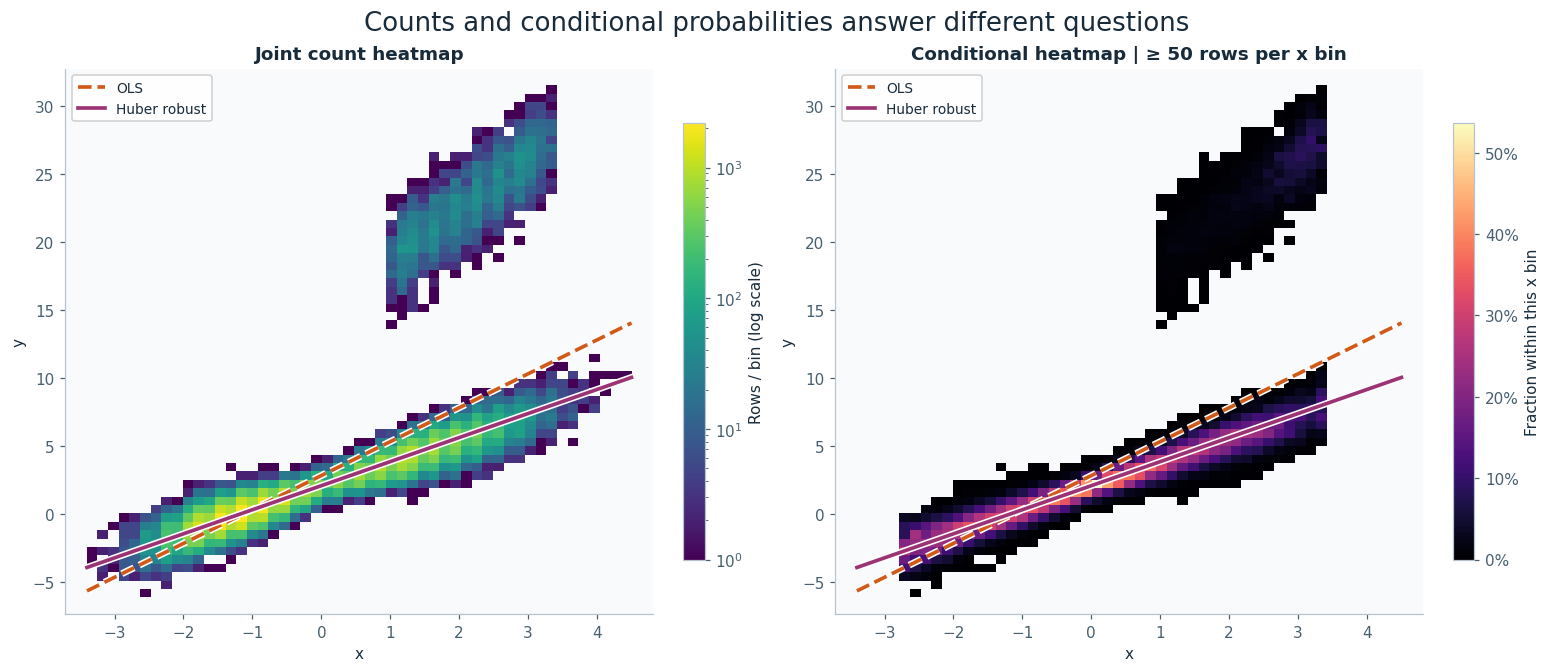

Conditional view hides 153 rows in 15 x bins below the support threshold (including empty bins).


In [16]:
conditional_counts, cond_x_edges, cond_y_edges = np.histogram2d(
    x, y, bins=(55, 65), range=[XLIM, YLIM])
column_totals = conditional_counts.sum(axis=1)
conditional_probability = np.divide(
    conditional_counts, column_totals[:, None], out=np.zeros_like(conditional_counts),
    where=column_totals[:, None] > 0)
MIN_COLUMN_ROWS = 50
well_supported = column_totals >= MIN_COLUMN_ROWS
conditional_view = np.ma.array(conditional_probability,
                               mask=(conditional_counts == 0) | (~well_supported[:, None]))
fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
fig.suptitle("Counts and conditional probabilities answer different questions", fontsize=17)
joint_image = axes[0].pcolormesh(
    cond_x_edges, cond_y_edges, np.ma.masked_equal(conditional_counts.T, 0),
    norm=LogNorm(vmin=1, vmax=max(2, conditional_counts.max())), cmap="viridis", rasterized=True)
conditional_image = axes[1].pcolormesh(
    cond_x_edges, cond_y_edges, conditional_view.T, cmap="magma", vmin=0,
    vmax=max(0.01, conditional_probability[well_supported].max()) if well_supported.any() else 1,
    rasterized=True)
for ax in axes:
    overlay_lines(ax, include_truth=False)
    ax.set(xlim=XLIM, ylim=YLIM, xlabel=X_LABEL, ylabel=Y_LABEL)
axes[0].set_title("Joint count heatmap")
axes[1].set_title(f"Conditional heatmap | ≥ {MIN_COLUMN_ROWS} rows per x bin")
fig.colorbar(joint_image, ax=axes[0], label="Rows / bin (log scale)", shrink=0.8)
fig.colorbar(conditional_image, ax=axes[1], label="Fraction within this x bin",
             format=PercentFormatter(xmax=1), shrink=0.8)
show_and_save(fig, "12_conditional_heatmap")
print(f"Conditional view hides {int(column_totals[~well_supported].sum()):,} rows "
      f"in {(~well_supported).sum()} x bins below the support threshold (including empty bins).")

### 8.6. Quantile fan: separate the centre from the tails

Extend the earlier median/IQR view into a fan with 5th–95th and 25th–75th percentile
bands. This is especially useful for changing spread or an asymmetric upper tail.
The displayed quantiles are computed within up to 24 x-quantile bins; their joins are
visual interpolation, not fitted quantile regression. Coarse bins mix variation across
x with residual variation. Neither band is a confidence interval or a calibrated
prediction interval for a new observation.

In the default example, the upper tail grows sharply where the shifted group becomes
a substantial fraction of a bin, even though the main trend remains approximately linear.

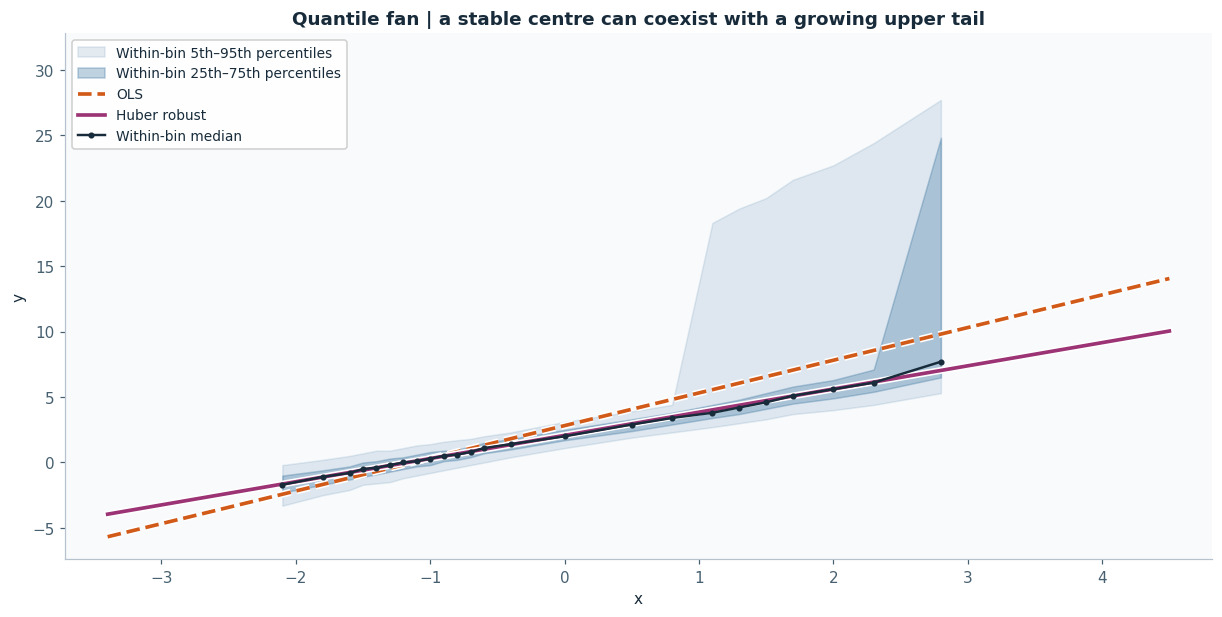

In [17]:
fan_bin = pd.qcut(data.x, q=min(24, data.x.nunique()), duplicates="drop")
fan_groups = data.assign(fan_bin=fan_bin).groupby("fan_bin", observed=True)
fan_quantiles = fan_groups.y.quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()
fan_x = fan_groups.x.median().to_numpy()
fig, ax = plt.subplots(figsize=(11, 5.5), layout="constrained")
ax.fill_between(fan_x, fan_quantiles[0.05], fan_quantiles[0.95], color=BLUE, alpha=0.13,
                label="Within-bin 5th–95th percentiles")
ax.fill_between(fan_x, fan_quantiles[0.25], fan_quantiles[0.75], color=BLUE, alpha=0.3,
                label="Within-bin 25th–75th percentiles")
overlay_lines(ax, include_truth=False)
ax.plot(fan_x, fan_quantiles[0.5], "o-", color=INK, ms=3, lw=1.6,
        label="Within-bin median", zorder=8)
ax.legend(loc="upper left", fontsize=9)
ax.set(title="Quantile fan | a stable centre can coexist with a growing upper tail",
       xlabel=X_LABEL, ylabel=Y_LABEL, xlim=XLIM, ylim=YLIM)
show_and_save(fig, "13_quantile_fan")

### 8.7–8.8. Binned boxplots and violins

Split the observed x range into eight equal-width intervals. Place each summary at its
interval midpoint, retaining the numeric x axis so the global OLS and Huber lines remain
interpretable. Each tick reports the number of rows in its interval.

**Boxplots** show the median and middle 50%. We deliberately choose 5th–95th percentile
whiskers and hide individual values outside them to avoid another overplotted scatter.
Thus tails beyond the whiskers are not shown. A box cannot reveal two separate peaks.
[Matplotlib boxplot options](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)

**Violins** estimate the shape of y within each interval and extend over its observed
range. All violins have the same maximum width, so width describes relative density
within a bin, not the number of observations. A second bulge can expose a subgroup,
although bandwidth can hide or invent apparent detail. Very small or constant groups
are shown as a median tick instead. [Matplotlib violinplot options](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.violinplot.html)

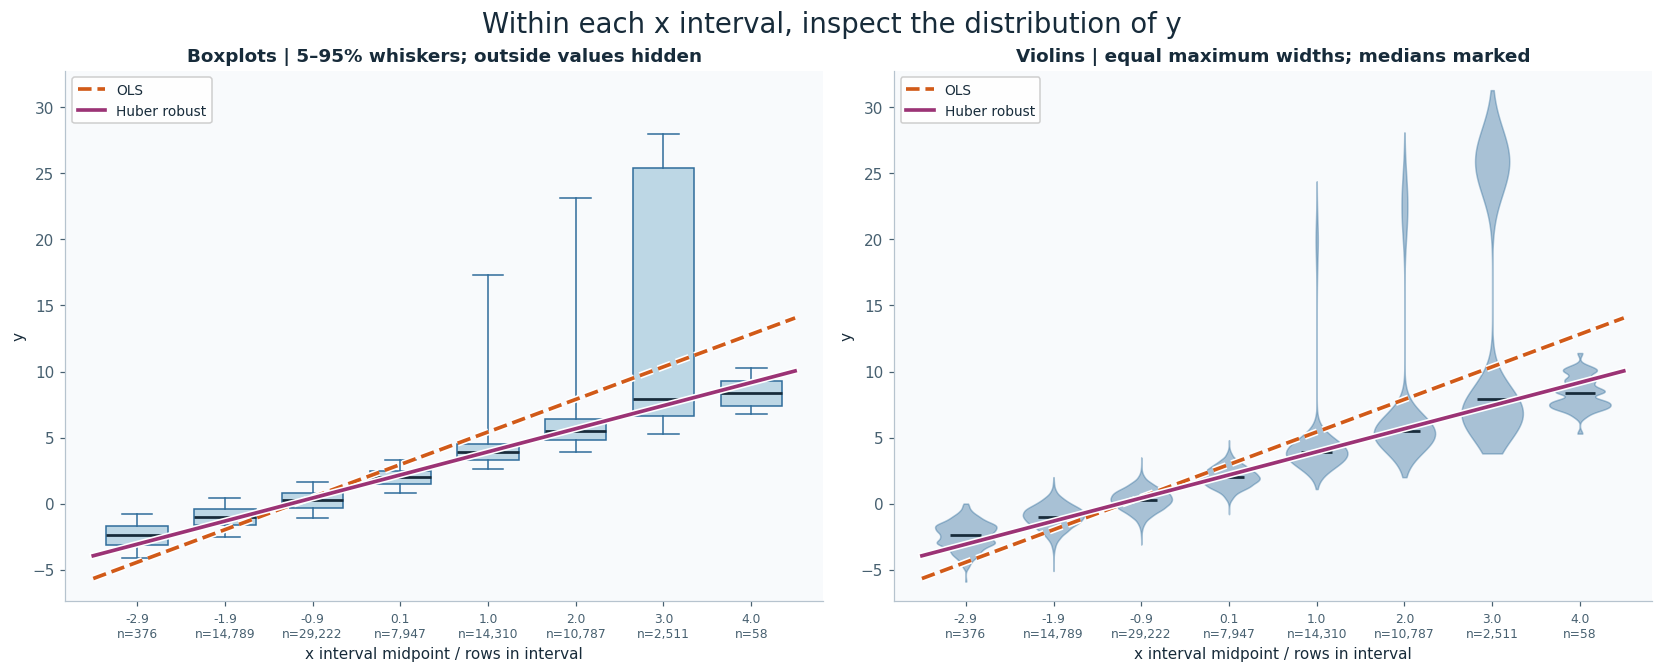

In [18]:
slice_edges = np.linspace(x.min(), x.max(), 9)
slice_id = np.clip(np.searchsorted(slice_edges, x, side="right") - 1, 0, 7)
occupied_slices = [i for i in range(8) if np.any(slice_id == i)]
slice_values = [y[slice_id == i] for i in occupied_slices]
slice_centres = np.array([(slice_edges[i] + slice_edges[i + 1]) / 2 for i in occupied_slices])
slice_median_x = np.array([np.median(x[slice_id == i]) for i in occupied_slices])
slice_width = (slice_edges[1] - slice_edges[0]) * 0.7
slice_tick_labels = [f"{p:.1f}\nn={len(values):,}" for p, values in zip(slice_centres, slice_values)]
fig, axes = plt.subplots(1, 2, figsize=(15, 6), layout="constrained")
fig.suptitle("Within each x interval, inspect the distribution of y", fontsize=18)
axes[0].boxplot(slice_values, positions=slice_centres, widths=slice_width,
                whis=(5, 95), showfliers=False, manage_ticks=False, patch_artist=True,
                boxprops={"facecolor": "#bdd7e5", "edgecolor": BLUE},
                medianprops={"color": INK, "linewidth": 1.8},
                whiskerprops={"color": BLUE}, capprops={"color": BLUE})
for values, position in zip(slice_values, slice_centres):
    if len(values) >= 3 and np.ptp(values) > 0:
        parts = axes[1].violinplot([values], positions=[position], widths=slice_width,
                                   showmedians=True, showextrema=False, bw_method=0.18, points=160)
        for body in parts["bodies"]:
            body.set(facecolor=BLUE, edgecolor=BLUE, alpha=0.4)
        parts["cmedians"].set(color=INK, linewidth=1.8)
    else:
        axes[1].plot(position, np.median(values), "_", color=INK, markersize=12)
for ax in axes:
    overlay_lines(ax, include_truth=False)
    ax.set(xlim=XLIM, ylim=YLIM, xlabel=f"{X_LABEL} interval midpoint / rows in interval", ylabel=Y_LABEL)
    ax.set_xticks(slice_centres, slice_tick_labels, fontsize=8)
axes[0].set_title("Boxplots | 5–95% whiskers; outside values hidden")
axes[1].set_title("Violins | equal maximum widths; medians marked")
show_and_save(fig, "14_boxplots_and_violins")

### 8.9. Ridgelines: compare whole distributions across x intervals

Reuse the same eight x intervals, now placing the distribution of **y on the horizontal
axis**. Each ridge is a histogram normalized to unit area before light Gaussian smoothing
(one histogram bin). A single height multiplier is shared by every ridge, so peak heights
remain comparable as densities. Counts appear in the labels; they are not encoded by area.

This orientation makes small secondary peaks and shifting tails easier to compare.
The vertical axis identifies x intervals; it is not a y measurement. The orange and magenta
markers locate the two full-data model predictions at the median x of each interval.
We do not draw a straight x–y regression line on these rearranged axes.

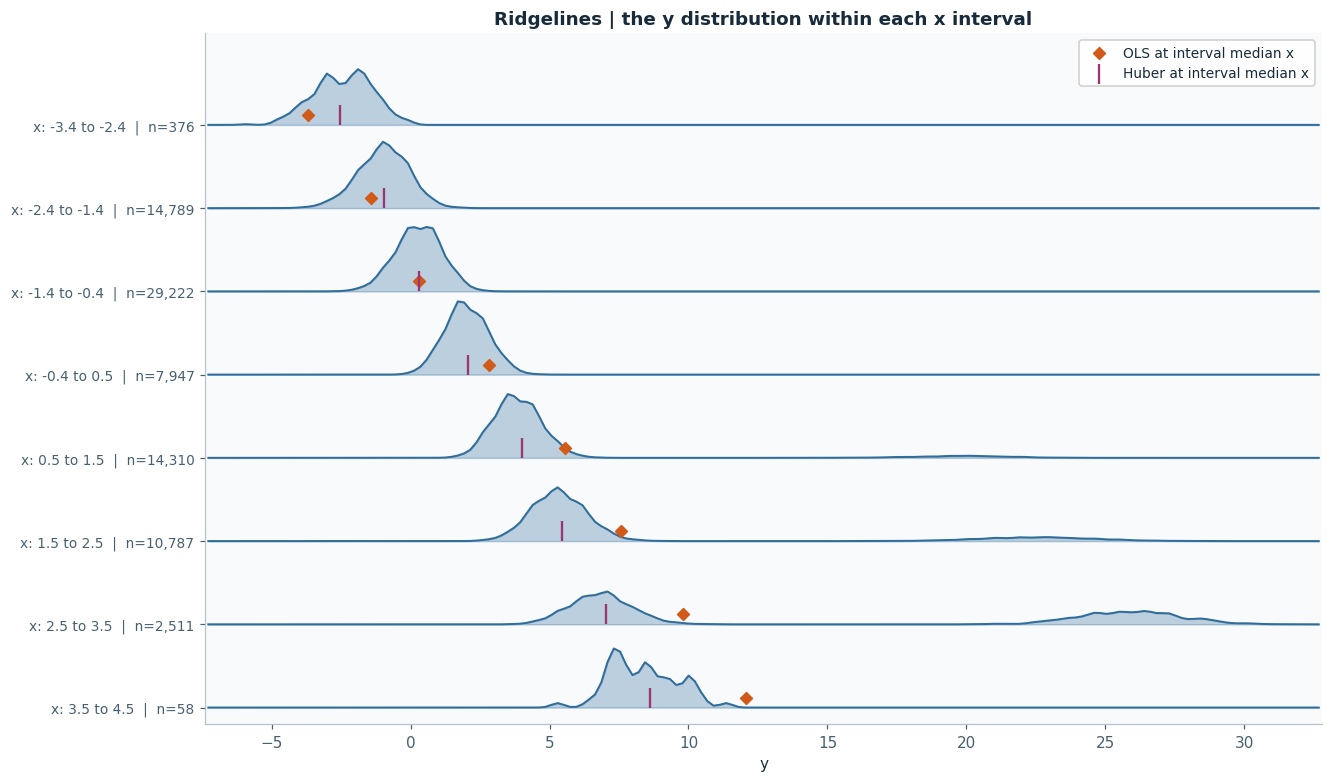

In [19]:
ridge_edges = np.linspace(*YLIM, 180)
ridge_y = (ridge_edges[:-1] + ridge_edges[1:]) / 2
ridge_densities = []
for values in slice_values:
    frequencies, _ = np.histogram(values, bins=ridge_edges, density=True)
    ridge_densities.append(gaussian_filter1d(frequencies, sigma=1, mode="constant"))
ridge_scale = 0.88 / max(d.max() for d in ridge_densities)
ridge_prediction_design = sm.add_constant(pd.DataFrame({"x": slice_median_x}), has_constant="add")
ridge_ols = np.asarray(ols.predict(ridge_prediction_design))
ridge_huber = np.asarray(huber.predict(ridge_prediction_design))
ridge_rows = np.arange(len(slice_values))[::-1]
fig, ax = plt.subplots(figsize=(12, 7), layout="constrained")
for j, (row, density) in enumerate(zip(ridge_rows, ridge_densities)):
    ax.fill_between(ridge_y, row, row + density * ridge_scale, color=BLUE, alpha=0.3)
    ax.plot(ridge_y, row + density * ridge_scale, color=BLUE, lw=1.3)
ax.scatter(ridge_ols, ridge_rows + 0.12, marker="D", s=30, color=ORANGE,
           label="OLS at interval median x", zorder=5)
ax.scatter(ridge_huber, ridge_rows + 0.12, marker="|", s=180, color=MAGENTA,
           label="Huber at interval median x", zorder=6)
ridge_labels = [f"x: {slice_edges[i]:.1f} to {slice_edges[i + 1]:.1f}  |  n={len(values):,}"
                for i, values in zip(occupied_slices, slice_values)]
ax.set_yticks(ridge_rows, ridge_labels, fontsize=9)
ax.set(xlim=YLIM, ylim=(-0.2, len(slice_values) + 0.1), xlabel=Y_LABEL,
       title="Ridgelines | the y distribution within each x interval")
ax.legend(loc="upper right", fontsize=9)
show_and_save(fig, "15_ridgelines")

### 8.10. Small multiples: separate meaningful groups

If observations belong to different devices, sites, cohorts, or operating regimes,
faceting may reveal more than another way to draw one pooled cloud. Use genuine group
labels and keep bin edges, axis limits, and colour normalization consistent across panels.

This **separate synthetic dataset** has three groups with a positive within-group
relationship, but the group centres move downward as x increases. A pooled model
therefore has a negative slope. Each panel fits its own OLS and Huber model to all its
observations, with the fitted line limited to that panel's observed x range.

Both pooled estimators miss the positive within-group relationship. Robust regression
does not account for group membership automatically. Which trend is relevant depends
on whether the question concerns within-group or between-group changes.

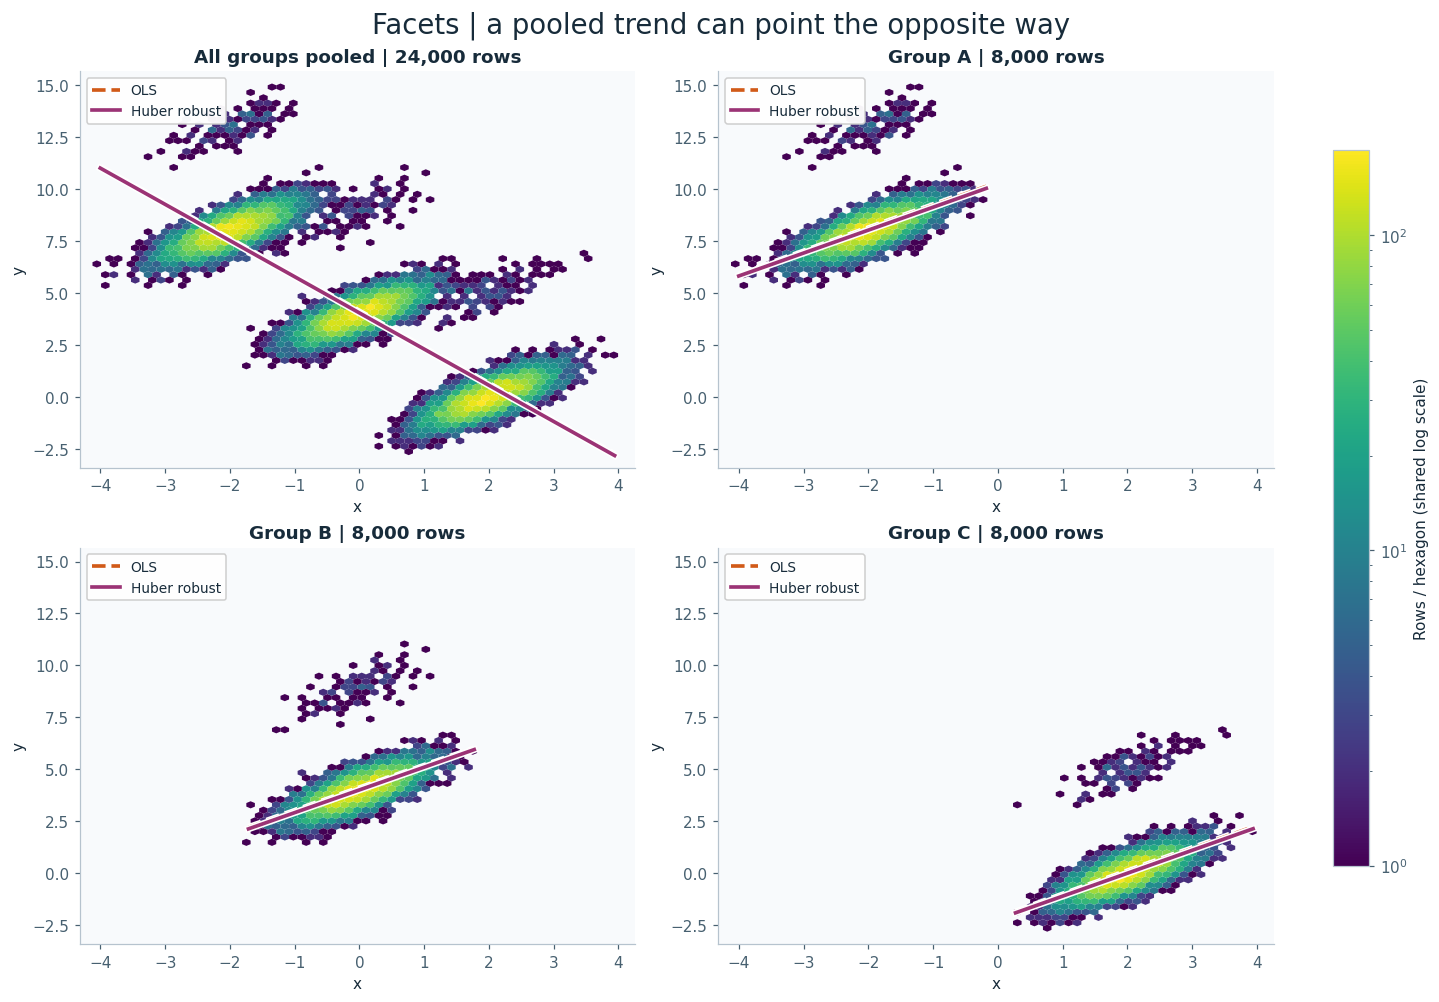

,OLS slope,Huber slope
data,,
All groups pooled,-1.739,-1.741
Group A,1.118,1.103
Group B,1.087,1.094
Group C,1.115,1.102


In [20]:
facet_rng = np.random.default_rng(SEED + 11)
facet_parts = []
for label, mean_x, mean_y in [("A", -2, 8), ("B", 0, 4), ("C", 2, 0)]:
    gx = facet_rng.normal(mean_x, 0.5, 8_000)
    gy = mean_y + 1.1 * (gx - mean_x) + facet_rng.normal(0, 0.5, len(gx))
    gy[facet_rng.random(len(gx)) < 0.015] += 5
    facet_parts.append(pd.DataFrame({"x": gx, "y": gy, "group": label}))
facet_data = pd.concat(facet_parts, ignore_index=True)
facet_frames = [("All groups pooled", facet_data)] + [
    (f"Group {label}", part) for label, part in facet_data.groupby("group")]
facet_xlim, facet_ylim = padded_limits(facet_data.x), padded_limits(facet_data.y)
facet_extent = (*facet_xlim, *facet_ylim)
fig, axes = plt.subplots(2, 2, figsize=(13, 9), layout="constrained")
fig.suptitle("Facets | a pooled trend can point the opposite way", fontsize=18)
facet_artists, facet_slopes = [], []
for ax, (label, part) in zip(axes.ravel(), facet_frames):
    facet_artists.append(ax.hexbin(part.x, part.y, gridsize=65, extent=facet_extent, mincnt=1,
                                   cmap="viridis", linewidths=0, rasterized=True))
    group_ols, group_huber = fit_lines(part[["x", "y"]])
    group_grid = np.linspace(part.x.min(), part.x.max(), 200)
    group_design = sm.add_constant(pd.DataFrame({"x": group_grid}), has_constant="add")
    overlay_lines(ax, grid=group_grid, ordinary_line=group_ols.predict(group_design),
                  robust_line=group_huber.predict(group_design), include_truth=False)
    ax.set(title=f"{label} | {len(part):,} rows", xlim=facet_xlim, ylim=facet_ylim,
           xlabel="x", ylabel="y")
    facet_slopes.append({"data": label, "OLS slope": group_ols.params["x"],
                         "Huber slope": group_huber.params["x"]})
facet_norm = LogNorm(vmin=1, vmax=max(a.get_array().max() for a in facet_artists))
for artist in facet_artists:
    artist.set_norm(facet_norm)
fig.colorbar(facet_artists[0], ax=axes.ravel().tolist(),
             label="Rows / hexagon (shared log scale)", shrink=0.82)
show_and_save(fig, "16_small_multiples")
display(pd.DataFrame(facet_slopes).set_index("data").round(3))

### Which of these should I try first?

For a general report, try the **joint plot with marginals**: it adds useful context
while keeping the main density and trends familiar. For changing variability or tails,
compare the **conditional heatmap** and **quantile fan**. For distinct populations,
use **facets** when group labels exist, or inspect **violins/ridgelines** when looking
for distributional structure. Use **contours** for a smooth overview and **bubbles**
when exact duplicate frequencies matter.

None of these is uniformly best. Choose the one that makes the feature you need to
communicate visible, and keep a count-based full-range view available as a reference.

## 9. Practical choices to carry into your next plot

1. **Keep a full-range view.** Sparse observations matter too. Label any crop, sample,
   jitter, or transformation and retain a view that reveals its effect.
2. **Use count aggregation when transparency saturates.** Try about 40–100 hexagons
   across the plot as a starting range, then check coarser and finer settings. A log
   colour scale is useful when counts span orders of magnitude.
3. **Separate display choices from estimation.** Fit on valid original rows. Repeated
   observations count repeatedly; drawing one marker per unique location must not
   silently change regression weights.
4. **Choose the trend to match the question.** OLS summarizes a linear conditional mean;
   Huber reduces sensitivity to large residuals. Neither accounts automatically for
   high leverage, multiple populations, dependence, or curvature. Facet meaningful
   subgroups instead of forcing one trend when their relationships differ.
5. **Distinguish spread and uncertainty.** The binned band above shows observation spread.
   If confidence bands are needed, choose inference appropriate for the estimator and
   dependence structure; do not attach an OLS band to a robust fit.
6. **Scale rendering deliberately.** For millions of points, aggregate counts in chunks
   using fixed bin edges, or use a pixel aggregation tool. Plot aggregation does not
   automatically make the full regression fit out-of-core. Rasterizing point/bin artists
   keeps SVG/PDF exports manageable while leaving labels and lines as vectors; it does
   not resolve overlap by itself.

[Matplotlib's rasterization guide](https://matplotlib.org/stable/gallery/misc/rasterization_demo.html)
explains the vector-export behaviour. If you try a smoothed density estimate (KDE),
check its bandwidth: smoothing can merge nearby groups or suggest density in empty gaps.
Counts are the simpler first diagnostic here.

**Try it:** set `OUTLIER_FRACTION = 0`, change the bin resolution, or increase `N` and rerun.
Watch when transparency saturates and when the fitted lines agree. On your own data,
compare the full-range density, residuals, and substantive meaning of the two trends.

### Execution checks

These checks verify that binning retained all observations, both regression methods used
all valid rows, and the reusable recipe reproduces the earlier fits. The synthetic example
also compares coefficient errors against its known generating values.

In [21]:
assert int(round(np.sum(hb.get_array()))) == len(data)
assert int(round(rect_counts.sum())) == len(data)
assert int(ols.nobs) == int(huber.nobs) == len(data)
assert np.isfinite(ols.params).all() and np.isfinite(huber.params).all()
assert np.isfinite(smooth_plain).all() and np.isfinite(smooth_robust).all()
assert np.all((np.asarray(huber.weights) > 0) & (np.asarray(huber.weights) <= 1))
np.testing.assert_allclose(recipe_results["ols"].params, ols.params)
np.testing.assert_allclose(recipe_results["huber"].params, huber.params)
assert int(exact_counts["count"].sum()) == len(data)
assert int(extra_counts.sum()) == len(data)
assert int(conditional_counts.sum()) == len(data)
np.testing.assert_allclose(conditional_probability[well_supported].sum(axis=1), 1.0)
assert sum(len(values) for values in slice_values) == len(data)
assert np.all(np.diff(fan_quantiles.to_numpy(), axis=1) >= 0)
assert int(sum(len(part) for _, part in facet_frames[1:])) == len(facet_data)
if IS_SYNTHETIC:
    coefficient_errors = pd.DataFrame({
        "OLS absolute error": np.abs(ols.params.to_numpy() - [2, 1.7]),
        "Huber absolute error": np.abs(huber.params.to_numpy() - [2, 1.7]),
    }, index=["intercept", "slope"])
    display(coefficient_errors.round(4))
print("Checks passed: count conservation, full-data fits, finite predictions, reusable recipe, "
      "conditional normalization, quantile ordering, and subgroup coverage.")
print(f"Figures saved in: {FIGURE_DIR.resolve()}")

,OLS absolute error,Huber absolute error
intercept,0.8181,0.0733
slope,0.7973,0.0711


Checks passed: count conservation, full-data fits, finite predictions, reusable recipe, conditional normalization, quantile ordering, and subgroup coverage.
Figures saved in: C:\projects\scatterplot\figures
